# LangGraph live optimization comparison across Trace / OTEL / sys.monitoring

This notebook runs the live comparison module and renders a shared analysis report.

- It uses the OpenRouter API when `OPENROUTER_API_KEY` is set.
- It defaults to `OPENROUTER_MODEL=google/gemini-3-flash-preview` when the model env var is absent.
- In CI or local runs without credentials, it prints a skip message and exits successfully.


## Optimization comparison

_Topology metrics remain useful even when score trajectories match, for example under the fixed offline prompt schedule._

| config | runtime_s | baseline | best | gain | best_iteration | stability_std | node_count | edge_count | score_history |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| trace | 76.856 | 0.842 | 0.872 | 0.030 | 3 | 0.112 | 9 | 6 | [0.842, 0.842, 0.568, 0.872, 0.64, 0.629] |
| trace+otel | 73.826 | 0.842 | 0.893 | 0.051 | 2 | 0.137 | 9 | 6 | [0.842, 0.842, 0.893, 0.573, 0.586, 0.571] |
| otel | 79.725 | 0.842 | 0.881 | 0.039 | 2 | 0.076 | 6 | 5 | [0.842, 0.842, 0.881, 0.745, 0.689, 0.702] |
| trace+sysmon | 71.576 | 0.842 | 0.890 | 0.048 | 4 | 0.095 | 9 | 6 | [0.842, 0.842, 0.714, 0.737, 0.89, 0.7] |
| trace+otel+sysmon | 89.682 | 0.842 | 0.876 | 0.034 | 3 | 0.038 | 9 | 6 | [0.842, 0.842, 0.8, 0.876, 0.805, 0.788] |
| otel+sysmon | 74.301 | 0.842 | 0.842 | 0.000 | 0 | 0.022 | 6 | 5 | [0.842, 0.842, 0.712, 0.72, 0.737, 0.675] |
| sysmon | 62.266 | 0.842 | 0.930 | 0.088 | 2 | 0.000 | 4 | 3 | [0.842, 0.842, 0.93, 0.93, 0.93, 0.93] |

### Prompt selection

| config | best_iteration | best update keys | best-scoring prompt | final attempted prompt |
|---|---:|---|---|---|
| trace | 3 | ['synth_prompt'] | Based on the following outline, provide a complete, direct, and factual explanation. En... | Act as an expert scientific writer. Your primary goal is to expand the provided outline... |
| trace+otel | 2 | ['synth_prompt'] | Provide a direct, factual answer to the query based on the plan provided below. Start y... | Act as a technical writer to generate a professional document based on the provided pla... |
| otel | 2 | ['planner_prompt', 'synth_prompt'] | Synthesize a clear, brief, and factual response to the query: {query}<br>Use these planned... | You are an expert science communicator and molecular biologist. Synthesize a profession... |
| trace+sysmon | 4 | ['synth_prompt'] | Synthesize the following plan into a complete, polished, and factual summary. <br><br>Maintai... | Synthesize the following plan into a complete, polished, and factual summary. <br><br>Maintai... |
| trace+otel+sysmon | 3 | ['synth_prompt'] | Provide a concise and direct answer to the query by synthesizing the provided plan. <br>En... | Provide a concise and direct answer to the query by synthesizing the provided plan. <br><br>Y... |
| otel+sysmon | 0 | [] | Answer briefly and factually: {query}<br>Plan: {plan} | Integrating every detail from the provided plan, write a sophisticated, single-paragrap... |
| sysmon | 2 | ['planner_prompt', 'synth_prompt'] | Answer briefly and factually using a clear, structured bulleted list: {query}<br>Plan: {plan} | Answer briefly and factually using a clear, structured bulleted list: {query}<br>Plan: {plan} |

## trace
- Runtime: `76.856s`
- Baseline score: `0.842`
- Best score: `0.872`
- Score gain: `0.030`
- Best iteration: `3`
- Post-update stability std: `0.112`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.842, 0.842, 0.568, 0.872, 0.64, 0.629]`
- Best update keys: `['synth_prompt']`

### Best-scoring synth prompt
```text
Based on the following outline, provide a complete, direct, and factual explanation. Ensure the response is cohesive, completes any unfinished thoughts in the plan, and avoids unnecessary introductory phrases.
Outline: {plan}
```
### Final attempted synth prompt
```text
Act as an expert scientific writer. Your primary goal is to expand the provided outline into a comprehensive, professional, and fully self-contained article.

Follow these strict constraints:
1. ABSOLUTE COMPLETION: The provided outline is intentionally incomplete or ends abruptly. You MUST use your expertise to fill in the missing information, bridge all gaps, and provide a logical progression to the end of the topic.
2. MANDATORY CONCLUSION: You must end the article with a formal "Conclusion" section that summarizes the key points. The response MUST NOT end mid-sentence or mid-thought.
3. FORMATTING: Use professional Markdown headings (e.g., #, ##, ###) and categorized bullet points for readability.
4. TONE: Maintain a formal, academic, and engaging scientific tone.
5. LENGTH MANAGEMENT: If the topic is broad, ensure you balance detail with the need to provide a complete narrative from introduction to conclusion within your response limit.

Outline to expand:
{plan}
```
### Final answer
```text
# CRISPR-Cas9: The Frontier of Genetic Engineering

### **1. The Definition: Understanding the Molecular Machinery**
CRISPR, an acronym for **Clustered Regularly Interspaced Short Palindromic Repeats**, represents the most significant breakthrough in biotechnology of the 21st century. At its core, CRISPR is a precision gene-editing technology that allows scientists to modify the DNA of living organisms with unprecedented accuracy.

To understand its function, it is often helpful to use the an...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node12_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Act as an expert scientific writer. Your primary goal is to expand the provided outline into a comprehensive, professional, and fully self-contained article.\n\nFollow these strict constraints:\n1. ABSOLUTE COMPLETION: T..."
}
```

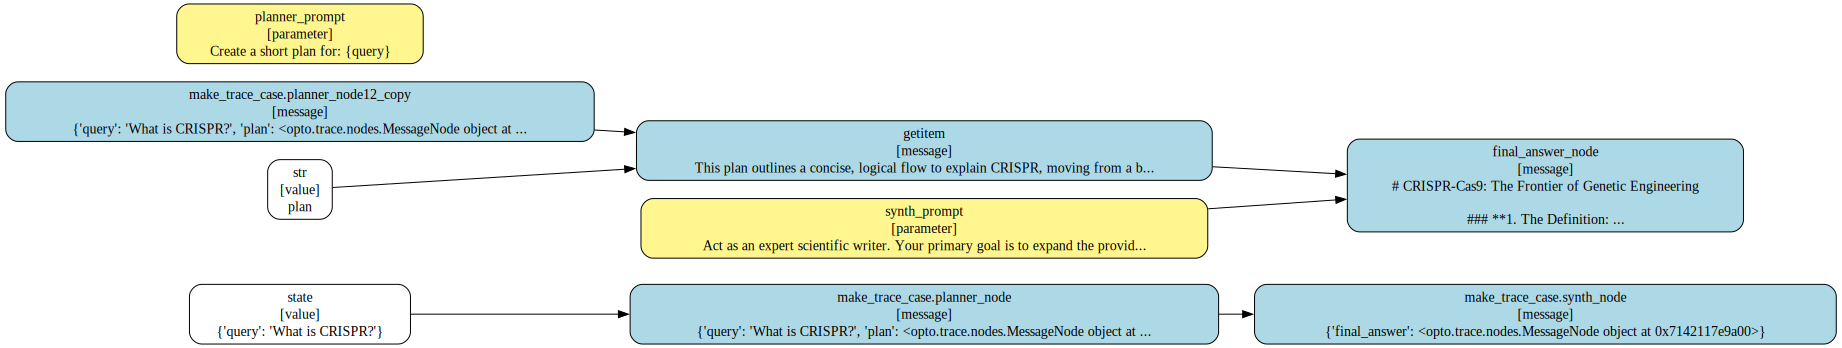

## trace+otel
- Runtime: `73.826s`
- Baseline score: `0.842`
- Best score: `0.893`
- Score gain: `0.051`
- Best iteration: `2`
- Post-update stability std: `0.137`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.842, 0.842, 0.893, 0.573, 0.586, 0.571]`
- Best update keys: `['synth_prompt']`

### Best-scoring synth prompt
```text
Provide a direct, factual answer to the query based on the plan provided below. Start your response immediately with the information requested without introductory filler. Ensure the response is logically structured and complete.

Query: {query}
Plan: {plan}
```
### Final attempted synth prompt
```text
Act as a technical writer to generate a professional document based on the provided plan.

CRITICAL INSTRUCTIONS:
1. ABSOLUTE DIRECTNESS: Begin the response immediately with the first heading or paragraph. Do not provide any introduction, prefix, or meta-commentary like "Here is the response...".
2. STRUCTURE: Use bolded Markdown headings (e.g., ### **Heading**) that correspond exactly to the sections in the Plan.
3. TRUNCATION HANDLING: If the provided Plan is cut off (truncated mid-sentence or mid-section), do not attempt to replicate the truncated fragment. Instead, logically conclude the current section and provide a final summary sentence to ensure the document is a complete, polished deliverable. 
4. COMPLETION GUARANTEE: The response MUST end with a full sentence and a period. Never leave a sentence unfinished or a list item trailing.
5. TECHNICAL DETAIL: Define all acronyms and provide technical context for all components mentioned (e.g., Cas9, gRNA, PAM). Use professional, factual language.

Query: {query}
Plan: {plan}
```
### Final answer
```text
### **Goal: To explain CRISPR as a revolutionary gene-editing tool.**

CRISPR represents a paradigm shift in biotechnology, offering a precise, efficient, and versatile method for altering the genetic code of living organisms. By leveraging a mechanism originally evolved in prokaryotes, scientists can now target specific sequences of Deoxyribonucleic Acid (DNA) to disable genes, correct mutations, or insert new genetic material.

### **1. The Definition (The "What")**

CRISPR is an acronym fo...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node25_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Act as a technical writer to generate a professional document based on the provided plan.\n\nCRITICAL INSTRUCTIONS:\n1. ABSOLUTE DIRECTNESS: Begin the response immediately with the first heading or paragraph. Do not prov..."
}
```

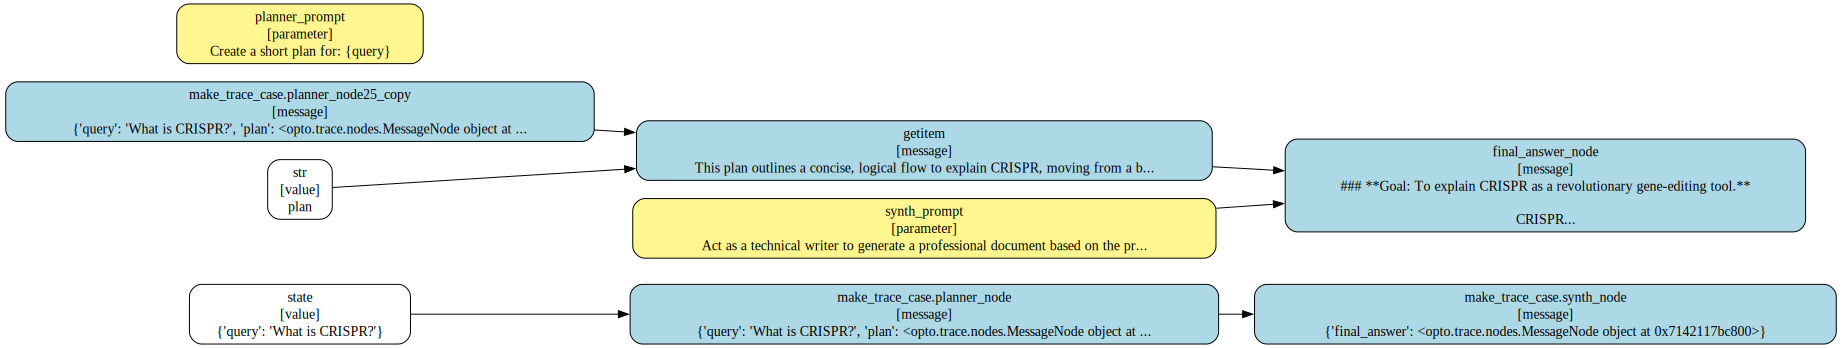

### observer otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `2`
- Span names: `['planner_node', 'synth_node']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Act as a technical writer to generate a professional document based on the provided plan.\n\nCRITICAL INSTRUCTIONS:\n1. ABSOLUTE DIRECTNESS: Begin the response immediately with the first heading or paragraph. Do not prov..."
}
```

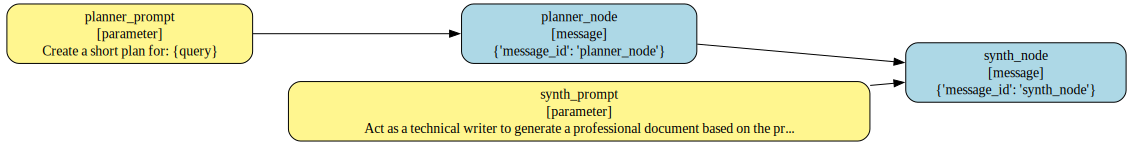

## otel
- Runtime: `79.725s`
- Baseline score: `0.842`
- Best score: `0.881`
- Score gain: `0.039`
- Best iteration: `2`
- Post-update stability std: `0.076`
- Node count: `6`
- Edge count: `5`
- Score history: `[0.842, 0.842, 0.881, 0.745, 0.689, 0.702]`
- Best update keys: `['planner_prompt', 'synth_prompt']`

### Best-scoring synth prompt
```text
Synthesize a clear, brief, and factual response to the query: {query}
Use these planned points as a guide: {plan}
```
### Final attempted synth prompt
```text
You are an expert science communicator and molecular biologist. Synthesize a professional, comprehensive, and cohesive academic essay responding to the query: "{query}".

Use the following points as your structural framework:
{plan}

Instructions:
- Expand significantly upon the provided points using your internal expertise to provide a deep dive into the biochemistry and practical implications.
- You must ensure the final essay covers three distinct areas: the fundamental definition/origin, the specific molecular mechanism (e.g., Cas9/gRNA interaction), and the broader implications or repair pathways (NHEJ/HDR).
- If the provided plan is missing the third component or ends abruptly, you are required to use your expertise to complete the framework and provide a full, high-quality explanation.
- Maintain a tone that is sophisticated, academic, and authoritative.
- Ensure seamless transitions between sections to create a single, unified narrative with an overarching logic.
- Do not include an introductory "Here is the response" preamble or a concluding summary of your own performance.
```
### Final answer
```text
### The Architecture of Precision: Understanding CRISPR-Cas9 as a Biological and Biotechnological Paradigm

The landscape of modern molecular biology was irrevocably altered by the discovery of CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats), a system that transitioned from an obscure observation in prokaryotic genomics to the most versatile tool in the geneticist’s arsenal. At its core, CRISPR represents a sophisticated intersection of evolutionary immunology and precision...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "Identify exactly three distinct and critical factual components required to explain \"{query}\". \nFor each component:\n1. Provide a clear, bolded heading.\n2. Provide a concise but complete 2-3 sentence explanation of tha...",
  "synth_prompt": "You are an expert science communicator and molecular biologist. Synthesize a professional, comprehensive, and cohesive academic essay responding to the query: \"{query}\".\n\nUse the following points as your structural fr..."
}
```

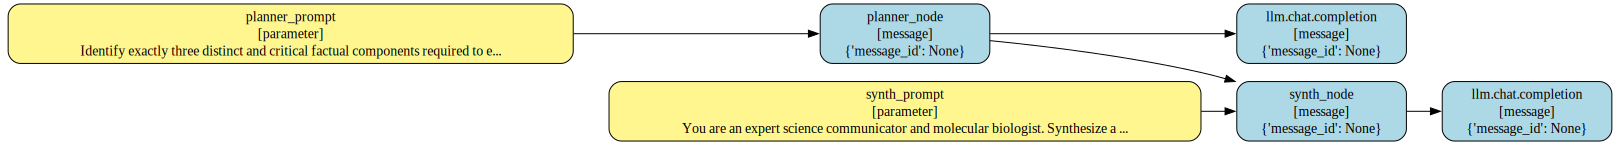

## trace+sysmon
- Runtime: `71.576s`
- Baseline score: `0.842`
- Best score: `0.890`
- Score gain: `0.048`
- Best iteration: `4`
- Post-update stability std: `0.095`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.842, 0.842, 0.714, 0.737, 0.89, 0.7]`
- Best update keys: `['synth_prompt']`

### Best-scoring synth prompt
```text
Synthesize the following plan into a complete, polished, and factual summary. 

Maintain the organizational structure of the plan by using clear headings and bullet points to ensure readability and information hierarchy. Even if the plan is incomplete or ends abruptly, use your knowledge to logically complete the narrative and provide a definitive concluding sentence.

Plan: {plan}
```
### Final attempted synth prompt
```text
Synthesize the following plan into a complete, polished, and factual summary. 

Maintain the organizational structure of the plan using clear headings and bullet points. Your primary goal is to provide a concise yet comprehensive overview. 

**Important:** If the provided plan is incomplete or cuts off mid-sentence, you MUST use your knowledge to provide a logical conclusion to those sections and ensure the narrative is fully realized. 

**Mandatory Ending:** You MUST conclude your entire summary with a single, definitive, and impactful final sentence, separated from the bullet points, that encapsulates the global significance of this technology.

Plan: {plan}
```
### Final answer
```text
### **CRISPR: A Revolutionary Tool for Genetic Engineering**

#### **1. The Definition (The "What")**
*   **Acronym:** CRISPR stands for **Clustered Regularly Interspaced Short Palindromic Repeats**, referring to unique sequences in the genome that serve as a hallmark of this system.
*   **The Analogy:** It is most commonly described as "molecular scissors" or a "search-and-replace" function for the code of life, allowing for the precise editing of DNA.
*   **The Components:**
    *   **Cas9:...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node38_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Synthesize the following plan into a complete, polished, and factual summary. \n\nMaintain the organizational structure of the plan using clear headings and bullet points. Your primary goal is to provide a concise yet c..."
}
```

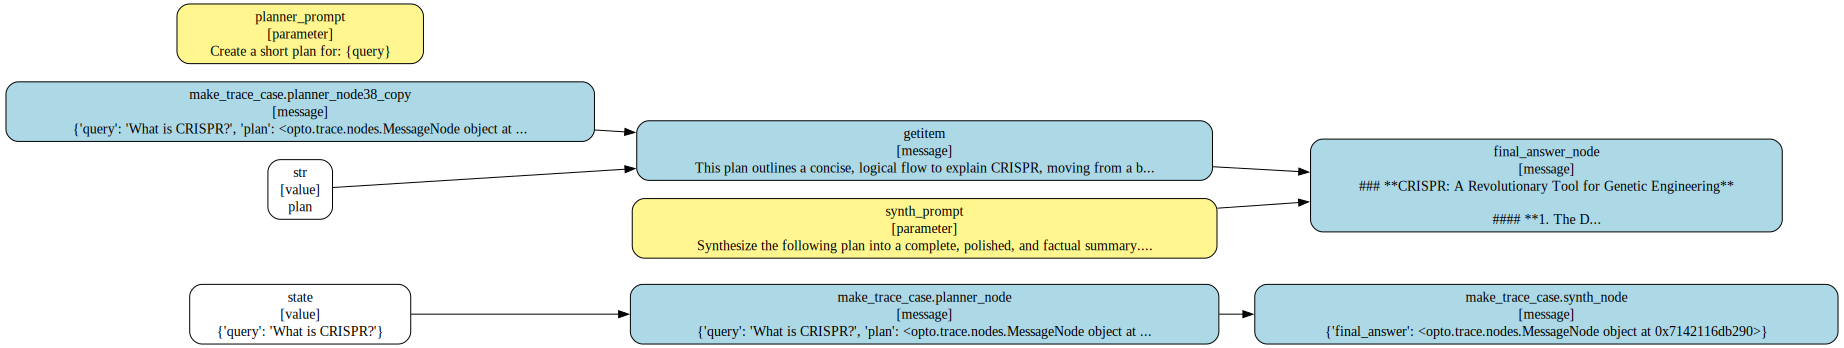

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Synthesize the following plan into a complete, polished, and factual summary. \n\nMaintain the organizational structure of the plan using clear headings and bullet points. Your primary goal is to provide a concise yet c..."
}
```

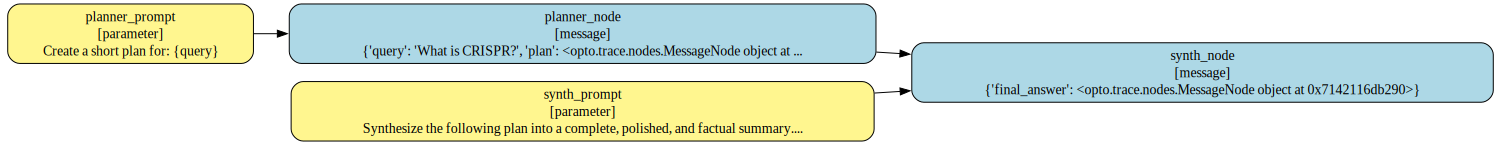

## trace+otel+sysmon
- Runtime: `89.682s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.034`
- Best iteration: `3`
- Post-update stability std: `0.038`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.842, 0.842, 0.8, 0.876, 0.805, 0.788]`
- Best update keys: `['synth_prompt']`

### Best-scoring synth prompt
```text
Provide a concise and direct answer to the query by synthesizing the provided plan. 
Ensure the response is structurally sound: all sentences must be complete, lists should be finalized, and any truncated information from the plan should be omitted or polished into a finished thought. Do not use introductory filler.
Query: {query}
Plan: {plan}
```
### Final attempted synth prompt
```text
Provide a concise and direct answer to the query by synthesizing the provided plan. 

Your response must follow these rules:
1. All sentences must be complete and grammatically correct. 
2. If the provided plan ends abruptly or contains incomplete bullet points, you must omit the unfinished point or rewrite it into a finished, logical sentence that concludes the thought.
3. Keep the synthesis focused strictly on the information provided in the plan.
4. You MUST wrap your entire response in &lt;answer&gt; and &lt;/answer&gt; tags. Ensure the closing tag is present.

Query: {query}
Plan: {plan}
```
### Final answer
```text
<answer>
CRISPR, which stands for Clustered Regularly Interspaced Short Palindromic Repeats, is a revolutionary gene-editing tool that functions like "molecular scissors" or a "search-and-replace" feature for DNA. The system consists of two primary components: the Cas9 enzyme, which performs the physical cut of the genetic material, and the Guide RNA (gRNA), which acts as a GPS to direct the enzyme to a specific genetic sequence. This technology was adapted from a naturally occurring immune s...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node51_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Provide a concise and direct answer to the query by synthesizing the provided plan. \n\nYour response must follow these rules:\n1. All sentences must be complete and grammatically correct. \n2. If the provided plan ends a..."
}
```

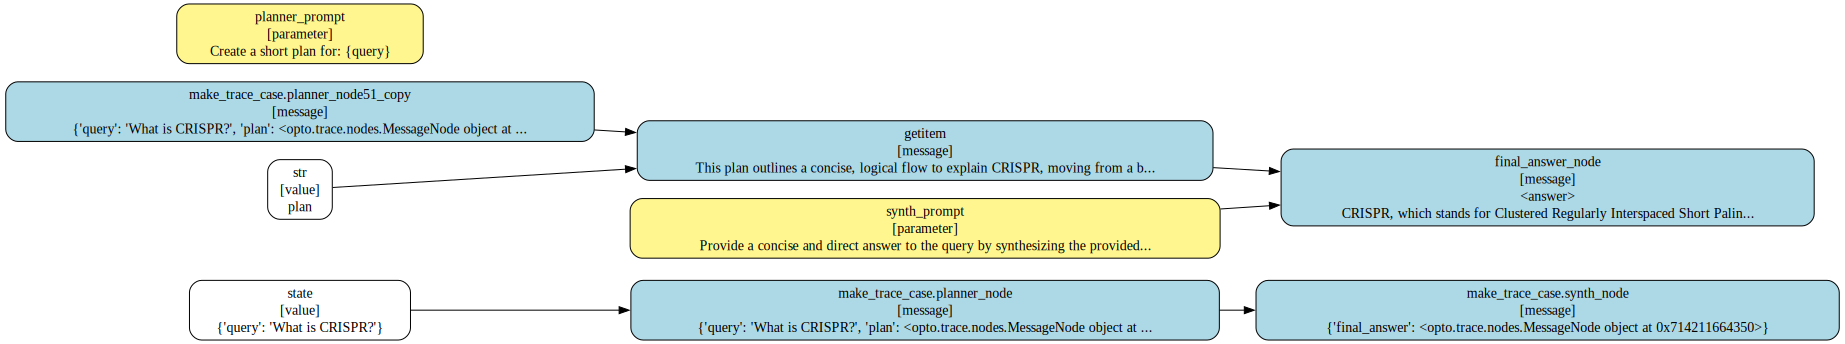

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Provide a concise and direct answer to the query by synthesizing the provided plan. \n\nYour response must follow these rules:\n1. All sentences must be complete and grammatically correct. \n2. If the provided plan ends a..."
}
```

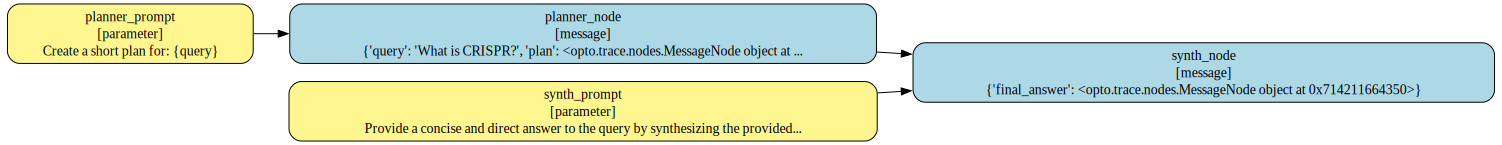

### observer otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `2`
- Span names: `['planner_node', 'synth_node']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Provide a concise and direct answer to the query by synthesizing the provided plan. \n\nYour response must follow these rules:\n1. All sentences must be complete and grammatically correct. \n2. If the provided plan ends a..."
}
```

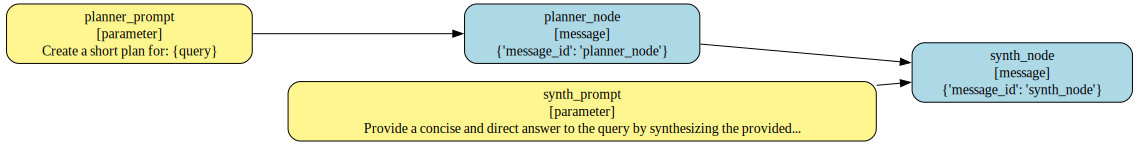

## otel+sysmon
- Runtime: `74.301s`
- Baseline score: `0.842`
- Best score: `0.842`
- Score gain: `0.000`
- Best iteration: `0`
- Post-update stability std: `0.022`
- Node count: `6`
- Edge count: `5`
- Score history: `[0.842, 0.842, 0.712, 0.72, 0.737, 0.675]`
- Best update keys: `[]`

### Best-scoring synth prompt
```text
Answer briefly and factually: {query}
Plan: {plan}
```
### Final attempted synth prompt
```text
Integrating every detail from the provided plan, write a sophisticated, single-paragraph academic narrative that answers: "{query}".

Plan: 
{plan}

Requirements:
- Strictly no lists, bullet points, or section headings.
- Weave the biological origins and molecular mechanics seamlessly into the discussion of modern applications.
- Use advanced vocabulary and maintain a high-level academic tone.
- Ensure every technical term and clinical/agricultural impact mentioned in the plan is included in the narrative.

Response:
```
### Final answer
```text
CRISPR, an acronym for Clustered Regularly Interspaced Short Palindromic Repeats, represents a sophisticated mechanism of adaptive immunity evolved by prokaryotes to archive a genetic memory of bacteriophage encounters by integrating viral fragments as spacers within their own genomic arrays. This biological defense system functions through a precise molecular surveillance apparatus wherein an effector complex scans for a Protospacer Adjacent Motif (PAM)—a critical binding signal that ensures...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "Create a detailed yet concise 4-point technical outline to explain \"{query}\". \nEnsure technical accuracy by mentioning specific biological components.\nStructure:\n1. Biological Origin: Define the system and its evoluti...",
  "synth_prompt": "Integrating every detail from the provided plan, write a sophisticated, single-paragraph academic narrative that answers: \"{query}\".\n\nPlan: \n{plan}\n\nRequirements:\n- Strictly no lists, bullet points, or section heading..."
}
```

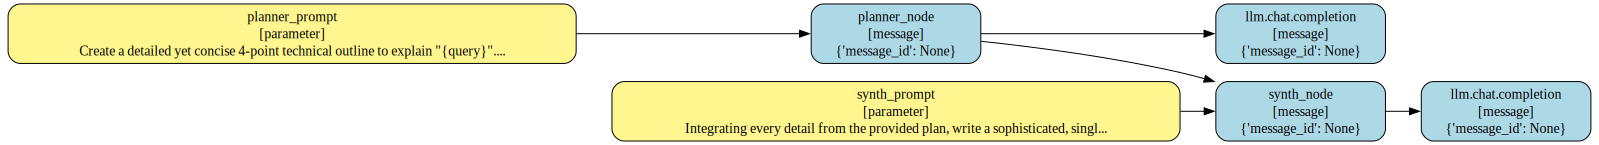

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a detailed yet concise 4-point technical outline to explain \"{query}\". \nEnsure technical accuracy by mentioning specific biological components.\nStructure:\n1. Biological Origin: Define the system and its evoluti...",
  "synth_prompt": "Integrating every detail from the provided plan, write a sophisticated, single-paragraph academic narrative that answers: \"{query}\".\n\nPlan: \n{plan}\n\nRequirements:\n- Strictly no lists, bullet points, or section heading..."
}
```

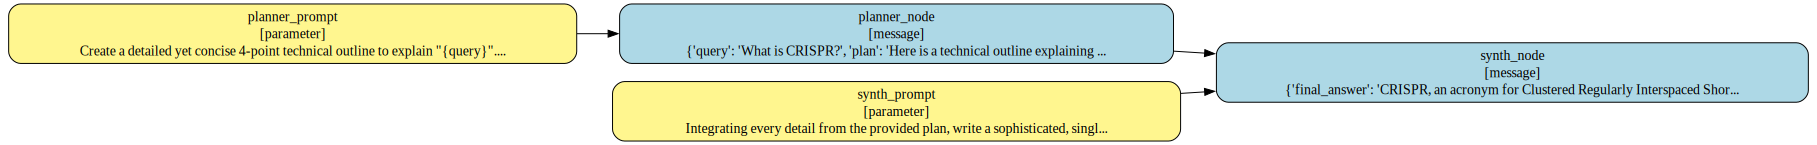

## sysmon
- Runtime: `62.266s`
- Baseline score: `0.842`
- Best score: `0.930`
- Score gain: `0.088`
- Best iteration: `2`
- Post-update stability std: `0.000`
- Node count: `4`
- Edge count: `3`
- Score history: `[0.842, 0.842, 0.93, 0.93, 0.93, 0.93]`
- Best update keys: `['planner_prompt', 'synth_prompt']`

### Best-scoring synth prompt
```text
Answer briefly and factually using a clear, structured bulleted list: {query}
Plan: {plan}
```
### Final attempted synth prompt
```text
Answer briefly and factually using a clear, structured bulleted list: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology. Here is a factual breakdown of its nature and function:

### **The Conceptual Foundation**
*   **Definition:** CRISPR is a molecular tool used to precisely edit DNA. It acts like a "search-and-replace" function for the genome, allowing scientists to add, remove, or alter genetic material.
*   **Biological Origin:** It is a natural immune system found in bacteria. Bacteria use CRISPR ...
```

### backend sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a structured, step-by-step plan for: {query}",
  "synth_prompt": "Answer briefly and factually using a clear, structured bulleted list: {query}\nPlan: {plan}"
}
```

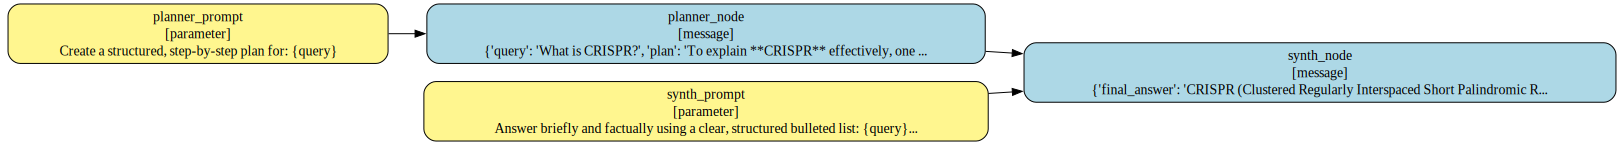

Captured 7 comparison rows.


In [1]:
import importlib.util
from pathlib import Path

candidates = [
    Path('examples/notebooks/demo_langgraph_instrument_and_compare_observers.py'),
    Path('demo_langgraph_instrument_and_compare_observers.py'),
]

for candidate in candidates:
    if candidate.exists():
        spec = importlib.util.spec_from_file_location('compare_observers_demo', candidate)
        module = importlib.util.module_from_spec(spec)
        assert spec.loader is not None
        spec.loader.exec_module(module)
        rows = module.run_notebook_demo()
        break
else:
    raise FileNotFoundError('Could not locate demo_langgraph_instrument_and_compare_observers.py')

print(f'Captured {len(rows)} comparison rows.')
